In [55]:
# import spacy as sp

# nlp = sp.blank("en")

# for token in doc:
#     print(token.text)

In [56]:
import spacy

nlp = spacy.blank("en")

# Process the text
doc = nlp(
    "In 1990, more than 600% of people in East Asia were in extreme poverty. "
    "Now less than 4% are."
)

# Iterate over the tokens in the doc
for token in doc:
    # Check if the token resembles a number
    if token.like_num:
        current_token = doc[token.i]
        print(current_token, '\n')

        # Get the next token in the document
        next_token = doc[token.i + 1]
        print(next_token)

        if next_token.text == "%":
            print("Percentage Found")

1990 

,
600 

%
Percentage Found
4 

%
Percentage Found


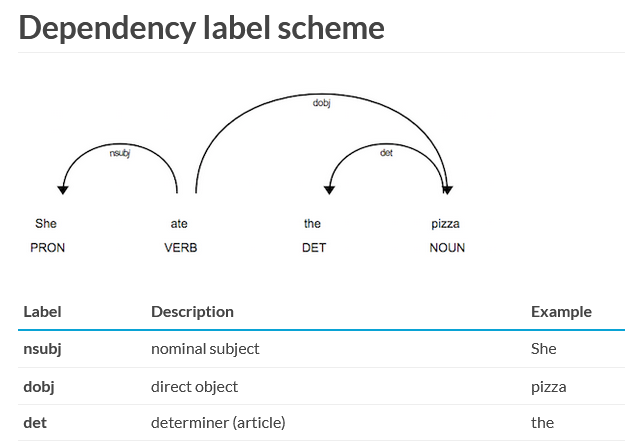

In addition to the part-of-speech tags, we can also predict how the words are related. For example, whether a word is the subject of the sentence or an object.

The .dep_ attribute returns the predicted dependency label.

The .head attribute returns the syntactic head token. You can also think of it as the parent token this word is attached to.


In [57]:
import spacy as sp
'''
Part-of-speech tags
Syntactic dependencies
Named entities
'''
# en_core_web_sm include model binary weights, Vocabs, Meta information, Configuration file
nlp = sp.load("en_core_web_sm")
doc = nlp("Named entities are 'real world objects' that are assigned a name – for example, a person, an organization or a country. \
The doc.ents property lets you access the named entities predicted by the named entity recognition model. \
It returns an iterator of Span objects, so we can print the entity text and the entity label using the .label_ attribute. \
In this case, the model is correctly predicting 'Apple' as an organization, 'U.K.' as a geopolitical entity and '$1 billion' as money.")

for token in doc:
    # token text, token Part-of-Speech, token Dependencu, token
    print(token.text, token.pos_, token.dep_, token.head.text)

Named VERB amod entities
entities NOUN nsubj are
are AUX ROOT are
' PUNCT punct objects
real ADJ amod world
world NOUN compound objects
objects NOUN attr are
' PART punct objects
that PRON nsubjpass assigned
are AUX auxpass assigned
assigned VERB ccomp objects
a DET det name
name NOUN dobj assigned
– PUNCT punct assigned
for ADP prep assigned
example NOUN pobj for
, PUNCT punct objects
a DET det person
person NOUN attr are
, PUNCT punct person
an DET det organization
organization NOUN conj person
or CCONJ cc organization
a DET det country
country NOUN conj organization
. PUNCT punct are
The PRON nsubj doc.ents
doc.ents VERB nsubj lets
property NOUN dobj doc.ents
lets VERB ROOT lets
you PRON nsubj access
access VERB ccomp lets
the DET det entities
named VERB amod entities
entities NOUN dobj access
predicted VERB acl entities
by ADP agent predicted
the DET det model
named VERB amod model
entity NOUN compound recognition
recognition NOUN compound model
model NOUN pobj by
. PUNCT punct let

In [58]:
doc = nlp("Miscrosoft í looking to buy VinFast in Viet nam")

for ent in doc.ents:
    print(ent, ent.label_)

Miscrosoft ORG
VinFast ORG
Viet nam GPE


In [59]:
print(sp.explain('GPE'))
print(sp.explain('ORG'))
print(sp.explain('NNP'))
print(sp.explain('compound'))

Countries, cities, states
Companies, agencies, institutions, etc.
noun, proper singular
compound


In [73]:
text = "It’s official: Apple is the first U.S. public company to reach a $1 trillion market value"

nlp = spacy.load("en_core_web_sm")
# Process the text
doc = nlp(text)

for token in doc.ents:
    # Get the token text, part-of-speech tag and dependency label
    token_text = token.text
    # token_pos = token.pos_
    # token_dep = token.dep_
    # token_head = token.head.text

    # # if token.like_num:
    # #     ent = doc[token.i].ents
    # #     print(ent)

    # # This is for formatting only
    # print(f"{token_text:<12}{token_pos:<10}{token_dep:<10}{token_head:<10}")
    print(f"{token_text:<12}")

Apple       
first       
U.S.        
$1 trillion 


In [87]:
text = "Upcoming iPhone X release date leaked as Apple reveals pre-orders"

# Process the text
doc = nlp(text)

# Iterate over the entities
for ent in doc.ents:
    # Print the entity text and label
    print(ent.text, ent.label_)

# Get the span for "iPhone X"
iphone_x = [ent for ent in doc[1:3]]

# # Print the span text
print("Missing entity:", iphone_x)

Apple ORG
Missing entity: [iPhone, X]


In [89]:
import spacy

# Import the Matcher
from spacy.matcher import Matcher

# Load a pipeline and create the nlp object
nlp = spacy.load("en_core_web_sm")

# Initialize the matcher with the shared vocab
matcher = Matcher(nlp.vocab)

# Add the pattern to the matcher
pattern = [{"TEXT": "iPhone"}, {"TEXT": "X"}]
matcher.add("IPHONE_PATTERN", [pattern])

# Process some text
doc = nlp("Upcoming iPhone X release date leaked")

# Call the matcher on the doc
matches = matcher(doc)
matches

[(9528407286733565721, 1, 3)]

In [ ]:
spacy.explain('LEMMA')

d:\Utilities\miniconda\envs\nlp\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'LEMMA' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
